In [ ]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,WriteConfig

In [102]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("./code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 56059
正在编译文件:  ./code/read_point3.txt
正在编译文件:  ./code/read_point3_col.txt
正在编译文件:  ./code/row_read_point3.txt
正在编译文件:  ./code/set_reset.txt
正在编译文件:  ./code/write_verify.txt
正在编译文件:  ./code/汇编测试代码.txt
正在编译文件:  ./code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ./code/读单点测试.txt


# 1.要写的权重

(100, 100)
0.16640375538417881 -0.13960279590415514


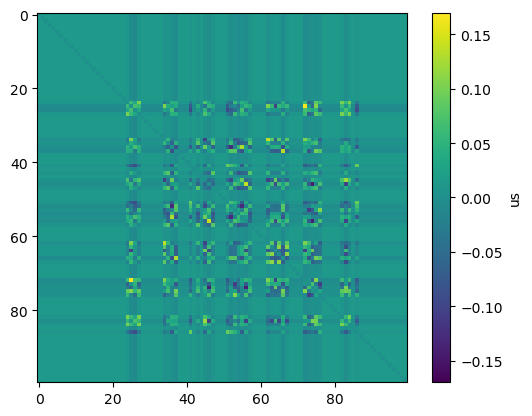

In [103]:
dl = DataLoader()
data = dl.load_csv("./data/HNN_W_matrix_origin.csv")
print(data.shape)
print(np.max(data),np.min(data))
plot_cond(data,vmin=-0.17,vmax=0.17)

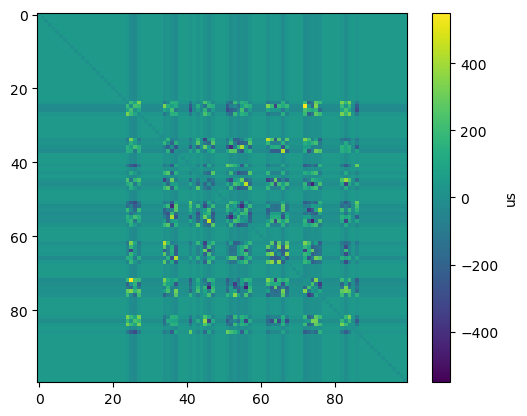

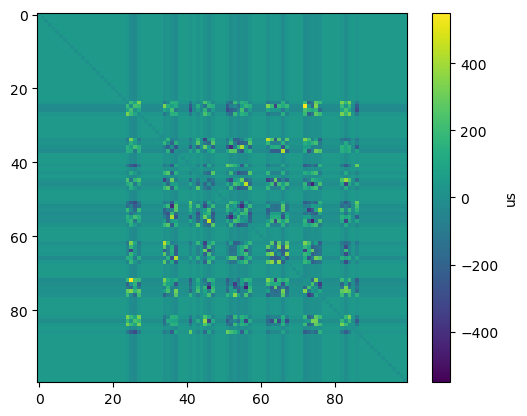

In [104]:
cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -0.17,0.17
target_cond = data/weight_max*cond_range
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range)
plot_cond(target_cond.T,vmin=-cond_range,vmax=cond_range)

In [ ]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

In [ ]:
good_device = np.load("./data/good_point_100_100_1_4.npy")

# 任意点

In [ ]:
threshold = 80

set_v,reset_v = 2,3
reset_pulse_width,set_pulse_width = 1e-6,1e-6
need_read = np.zeros((256,256),dtype=bool)
target = np.ones((256,256))

pos = np.ix_(good_device[0], good_device[1])


target[pos] = (target_cond + cond_reference).T
tg_v = target*slope+intercept-0.3
need_read[pos] = True


for i in range(100):
    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond(cond[pos]-cond_reference,vmin=-cond_range,vmax=cond_range)

    condition_reset = (cond > (target+threshold)) & need_read
    condition_set = (cond < (target-threshold)) & need_read
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    if i>0:
        # set_v = set_v+0.025
        # if i<5:
        #     tg_v[condition_reset] -= 0.04
        #     tg_v[condition_set] += 0.04
        # elif i<10:
        #     tg_v[condition_reset] -= 0.02
        #     tg_v[condition_set] += 0.02
        # else:
        tg_v[condition_reset] -= 0.04
        tg_v[condition_set] += 0.02

    tg_v.clip(0,3,out=tg_v)

    chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
    chip.write_point2(crossbar=condition_reset,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
    # # chip.ps.set_time_out(100)
    chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


# 一块区域

In [ ]:
good_device = np.load("./data/good_point_100_100.npy")
pos = (10,110,10,110)
target_cond_new = target_cond + cond_reference
target_cond_new = target_cond_new.T
threshold = 50

set_v,reset_v = 5,2
reset_pulse_width,set_pulse_width = 1e-6,1e-6
reset_cond = np.zeros((256,256),dtype=bool)
set_cond = np.zeros((256,256),dtype=bool)

tg_v = np.ones((256,256))
tg_v[pos[0]:pos[1],pos[2]:pos[3]] = target_cond_new*slope+intercept
for i in range(10):
    voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond(cond-cond_reference,vmin=-cond_range,vmax=cond_range)

    condition_reset = (cond > (target_cond_new+threshold)) 
    condition_set = (cond < (target_cond_new-threshold)) 
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    reset_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_reset
    set_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_set

    sacle = 1
    if i>0:
        # set_v = set_v+0.025
        # if i<5:
        #     tg_v[reset_cond] -= 0.04
        #     tg_v[set_cond] += 0.04*sacle
        # elif i<10:
        #     tg_v[reset_cond] -= 0.02
        #     tg_v[set_cond] += 0.02*sacle
        # else:
        tg_v[reset_cond] -= 0.01
        tg_v[set_cond] += 0.01*sacle

    # tg_v.clip(0,3,out=tg_v)

    # # reset的点
    chip.write_point2(crossbar=reset_cond,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
    chip.write_point2(crossbar=reset_cond,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    # chip.ps.set_time_out(20)
    # # set的点
    chip.write_point2(crossbar=set_cond,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width*10,set_device=True)


-0.17048933626174634


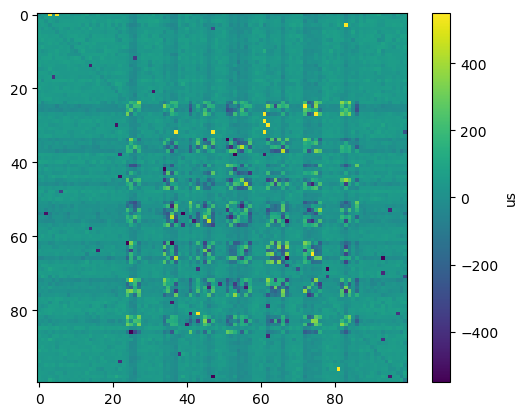

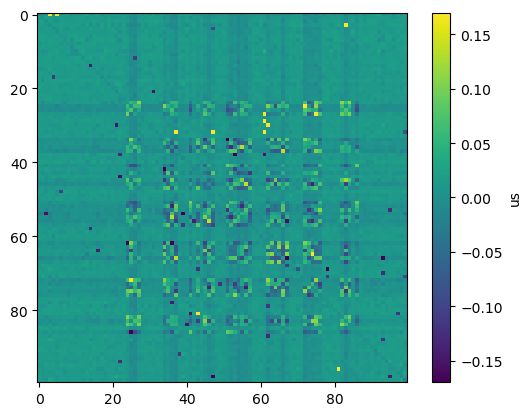

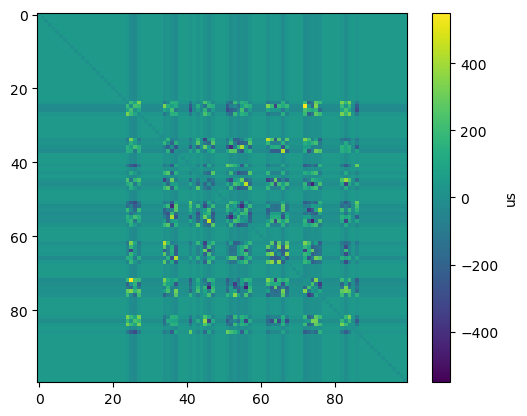

In [ ]:

voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[pos]
cond = cond -cond_reference

W = cond/cond_range*0.17

plot_cond(cond,vmin=-cond_range,vmax=cond_range)
plot_cond(W,lll=-0.17,vmax=0.17)
plot_cond(target_cond.T,vmin=-cond_range,vmax=cond_range)

In [98]:
steps=10

(100,)
(100,)
(100,)
(100,)
(100,)


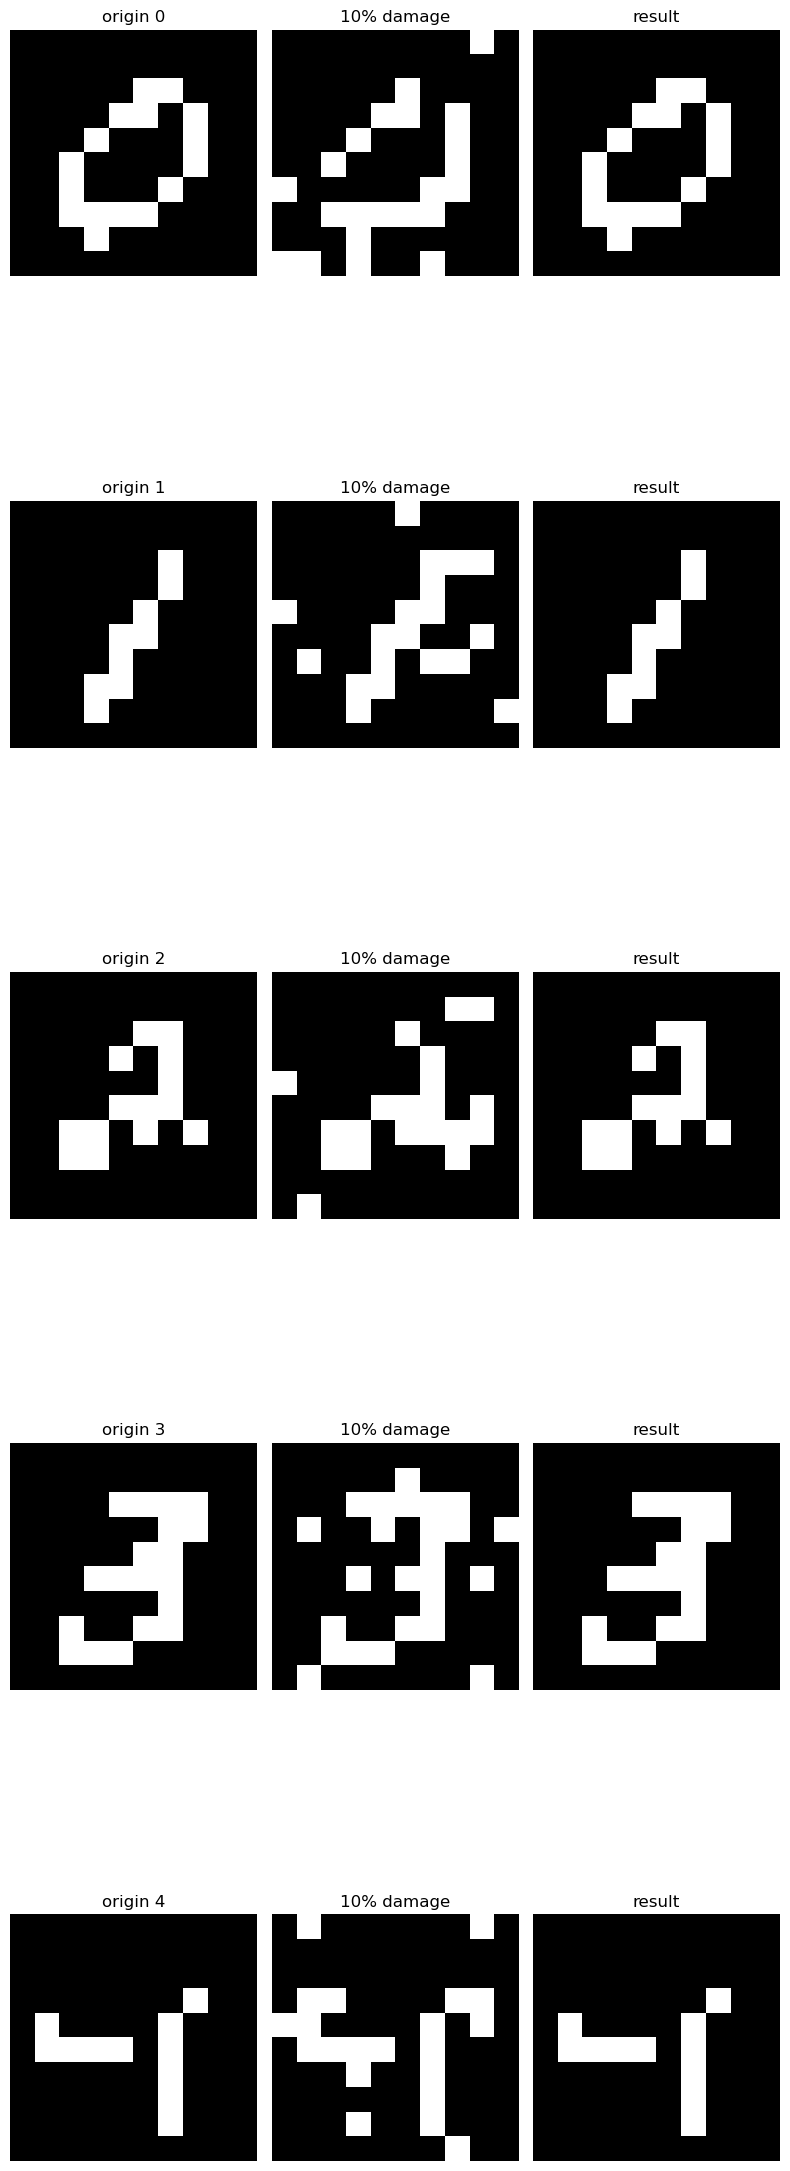

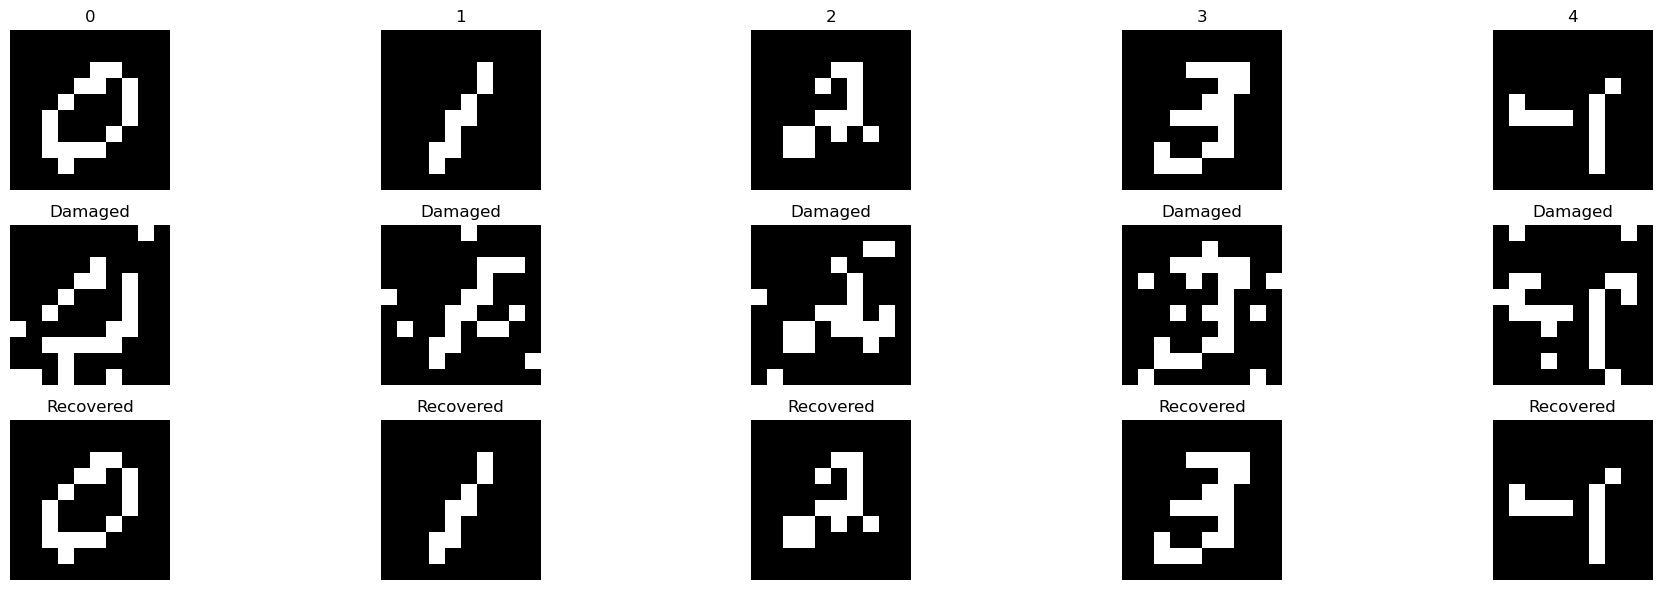

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.transform import resize
# -----------------------------
# 可调参数：网络总神经元数量（必须为完全平方数，如100、400、784等）
net_size = 100  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长

# -----------------------------
# 1. 加载 MNIST 数据，选取数字 0～9 各一张图
(train_images, train_labels), _ = mnist.load_data()

selected_patterns = []
for digit in range(num_imgs):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx]
    selected_patterns.append(img)


# 1.new

# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.io
#
# def load_mat_file(filename):
#     """
#     读入 .mat 文件，返回其中第一个非系统变量对应的矩阵
#     """
#     mat_data = scipy.io.loadmat(filename)
#     # 筛选掉 '__header__', '__version__', '__globals__' 等系统变量
#     keys = [key for key in mat_data.keys() if not key.startswith('__')]
#     # 假设第一个非系统变量就是我们需要的矩阵
#     return mat_data[keys[0]]
#
# def binarize_matrix(matrix, threshold=0):
#     """
#     将矩阵二值化：大于 threshold 的取 1，否则取 -1
#     """
#     return np.where(matrix > threshold, 1, -1)
#
# # 文件夹路径及状态列表
# folder = 'hnndata'
# selected_patterns = []
#
# # 依次加载 1.mat 到 10.mat
# for i in range(1, 11):
#     filename = f"{folder}/{i}.mat"
#     mat_matrix = load_mat_file(filename)  # 读入矩阵
#     print(mat_matrix)
#     # 二值化（根据实际情况可以调整 threshold，这里 threshold 设为 0）
#     bin_matrix = binarize_matrix(mat_matrix, threshold=0.1)
#     print(bin_matrix)
#     selected_patterns.append(bin_matrix)

# -----------------------------
# 2. 定义预处理函数：缩放 + 二值化
def preprocess_image(img, side, threshold=128):
    """
    缩放原始图像到 side x side，并二值化（像素值 > threshold 记为 +1，其它记为 -1）
    """
    # 缩放图像到 side x side（返回浮点型，值在0-1之间）
    img_resized = resize(img, (side, side), anti_aliasing=True)
    # 还原到0-255范围
    img_resized = img_resized * 255
    # 二值化
    bin_img = np.where(img_resized > threshold, 1, -1)
    return bin_img


# 对选取的图像进行预处理
processed_patterns = [preprocess_image(p, side) for p in selected_patterns]

# processed_patterns = selected_patterns



import numpy as np

# 假设 W 是你的 numpy 数组
# W = np.array([...])  # 用你的数据替换此处

# 1. 找到 W 中的最小值和最大值
# W_min = W.min()
# W_max = W.max()
#
# # 2. 将 W 归一化到 [0, 1] 范围内
# W_normalized = (W - W_min) / (W_max - W_min)
#
# # 3. 将归一化后的结果扩展到 [0, 15]，并四舍五入到最接近的整数
# W_quantized = np.round(W_normalized * 15)
#
# # 4. 可选：转换数据类型为无符号8位整数
# W_quantized = W_quantized.astype(np.uint8)
#
# print(W_quantized)
# W_dequantized = W_quantized / 15 * (W_max - W_min) + W_min
#
#
# W = W_dequantized

# -----------------------------
# 4. 定义异步更新函数（回忆过程）
def hopfield_recall(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1/-1）
    W: 训练好的权重矩阵
    steps: 更新次数上限
    返回: 收敛后的状态（side x side）
    """
    state_flat = state.flatten()
    N = state_flat.size
    for _ in range(steps):
        i = np.random.randint(0, N)  # 随机选择一个神经元
        h_i = np.dot(W[i, :], state_flat)
        state_flat[i] = 1 if h_i >= 0 else -1
    return state_flat.reshape((side, side))


def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    print(state_flat.shape)
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        # new_state = np.where(forward(state_flat) >= 0, 1, -1)
        new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)
        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))


import numpy as np

# -----------------------------
# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))


# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.1 # 例如翻转 30% 像素

for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=steps)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

# -----------------------------
# 7. 可视化展示原始、损坏与回忆后的图像
fig, axes = plt.subplots(num_imgs, 3, figsize=(8, 25))
for i in range(num_imgs):
    axes[i, 0].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 0].set_title(f"origin {i}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 1].set_title("10% damage")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 2].set_title("result")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# pos = (30,130,20,120)
# voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
# voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
# cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
# plot_cond(cond-700,vmin=-500,vmax=500)

# target_cond2 = target_cond-(cond-700)+700

# plot_cond(target_cond2,vmin=0,vmax=1000)

# plot_cond(target_cond2+cond-700,vmin=0,vmax=1000)

In [ ]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)-700
plot_cond(cond,vmin=-500,vmax=500)

pos = (150,250,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
target_cond2 = chip.voltage_to_cond(voltage=voltage-voltage_base)-1400

plot_cond(target_cond2,vmin=-500,vmax=500)

plot_cond(target_cond2+cond,vmin=-500,vmax=500)

In [ ]:
pos = (150,250,20,120)
target_cond_new = target_cond2
target_cond_new = target_cond_new.clip(50,1200)
threshold =25

set_v,reset_v = 2,2
reset_pulse_width,set_pulse_width = 1e-6,1e-6
need_write = np.ones((100,100),dtype=bool)
reset_cond = np.zeros((256,256),dtype=bool)
set_cond = np.zeros((256,256),dtype=bool)

tg_v = np.ones((256,256))*1.4
for i in range(20):
    voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond(cond-700,vmin=-500,vmax=500)

    condition_reset = (cond > (target_cond_new+threshold)) 
    condition_set = (cond < (target_cond_new-threshold)) 
    need_write = condition_reset + condition_set
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    reset_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_reset
    set_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_set

    if i>0:
        set_v+=0.1
        # reset_v+=0.01
        if i<5:
            tg_v[reset_cond] -= 0.08
            tg_v[set_cond] += 0.08
        elif i<10:
            tg_v[reset_cond] -= 0.04
            tg_v[set_cond] += 0.04
        else:
            tg_v[reset_cond] -= 0.01
            tg_v[set_cond] += 0.01

    # reset的点
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=5,pulse_width=10e-6,set_device=False)
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    # set的点
    chip.write_point2(crossbar=set_cond,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


In [ ]:
hnn = Layer(chip)
write_config = WriteConfig()
hnn.set_weight(weight=data,min_weight=-0.2,max_weight=0.2,pos=(40,240,20,120),weight_diff=True)
hnn.weight_setting(min_cond=200,max_cond=1000)
weight_cond = hnn.weight_to_cond(hnn.weight_target)
plot_cond(weight_cond,vmin=-800,vmax=800)

In [ ]:
def forward(self,state_flat:np.ndarray):
    """
        state_flat:为1*100的np数组
        split_type = 0,就是采用
    """
    x1,x2,y1,y2 = self.pos
    # 先处理正输入
    col_index = np.where(state_flat > 0)[1]+y1
    col_index = col_index.tolist()
    if col_index:
        v_base = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                            from_row=not self.weight_transpose,out_type=0,compute=True)
        v_pos = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        # 返回的是200*1的np数组
        v_cond_pos = self.chip.voltage_to_cond(v_pos-v_base)

    else:
        v_cond_pos = np.zeros((y2-y1,1))
    
    # 再处理负输入
    col_index = np.where(state_flat < 0)[1]+y1
    col_index = col_index.tolist()
    if col_index:
        v_base = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        v_neg = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        v_cond_neg = self.chip.voltage_to_cond(v_neg-v_base)
    else:
        v_cond_neg = np.zeros_like(v_cond_pos)
    v_cond = v_cond_pos - v_cond_neg
    v_cond = self.diff_cond_to_cond(v_cond)
    
    return self.cond_to_weight(v_cond)


In [ ]:
x = np.ones((1,100))
ans = forward(hnn,x).T
print(ans.shape)
print(ans)

In [ ]:
hnn.write_weight2(write_config=write_config,write_verify_time=40,threshold=100,reset=True)
# hnn.write_weight(write_config=WriteConfig,loop_times=10,write_verify_time=30,threshold=50,reset=True)

In [ ]:
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
def write_weight2(self:Layer,write_config:WriteConfig,write_verify_time = 10,threshold = 25,reset = False):
    """
        正负权重分开写
    """
    pos = self.pos
    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    if reset:
        self.reset_pos(pos,write_config)
    if self.weight_diff:
        read_weight = self.read_cond_point(pos,write_config.from_row)
        print(read_weight.shape)
        diffcond = self.diff_cond_to_cond(read_weight)
        plot_cond(diffcond,vmin=-2000,vmax=2000)
        print(target_cond.shape,diffcond.shape)
        # 写差分权重小于600的器件
        target_cond = -self.get_write_target_cond(target_cond,pos,diffcond,0)
        need_write = self.get_write_addr(need_write,pos,0) & (target_cond>600)
        target_cond.clip(0,1000,out=target_cond)
        self.write_verify(write_time=int(write_verify_time),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)

        # 写差分权重大于600的器件
        target_cond = self.get_write_target_cond(target_cond,pos,diffcond,0)
        need_write = self.get_write_addr(need_write,pos,0) & (target_cond>600)
        target_cond.clip(0,1000,out=target_cond)
        self.write_verify(write_time=int(write_verify_time),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)
write_weight2(hnn,write_config=write_config,write_verify_time=10,threshold=100,reset=True)

cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
hnn.reset_pos(hnn.pos,write_config=write_config)
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1400)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
# def write_verify(self,write_time,need_read,target_cond,threshold,write_config:WriteConfig):
x1,x2,y1,y2 = hnn.pos
need_write = np.zeros((256,256),dtype=bool)
target_cond = np.zeros((256,256))

need_write[x1:x2,y1:y2] = True
target_cond[x1:x2,y1:y2] = 1000

hnn.write_verify(20,need_write,target_cond,threshold=25,write_config=write_config)

In [ ]:
hnn.reset_pos(hnn.pos,write_config=write_config)
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-1000,vmax=1000)

In [ ]:
hnn.weight_setting(min_cond=200,max_cond=800)
def write_weight(self,write_config:WriteConfig,write_verify_time = 10,threshold = 25,reset = False):
    pos = self.pos

    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    weight_cond = self.weight_to_cond_target(self.weight_target)
    plot_cond(weight_cond,vmin=-800,vmax=800)

    cond_neg = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=1)
    target_cond = self.get_write_target_cond(target_cond,pos,weight_cond+cond_neg,0)
    plot_cond(target_cond,vmin=0,vmax=800)
    need_write = self.get_write_addr(need_write,pos,0) & (target_cond>0)
    plot_cond(need_write,vmin=0,vmax=1)
    plot_cond(self.read_cond_point(pos,write_config.from_row))

    target_cond=self.cond_to_diff_cond(target_cond[pos[0]:pos[1],pos[2]:pos[3]],0)
    plot_cond(target_cond-cond_neg,vmin=-1000,vmax=1000)





    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    weight_cond = self.weight_to_cond_target(self.weight_target)
    
    cond_pos = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=0)
    target_cond = self.get_write_target_cond(target_cond,pos,cond_pos-weight_cond,1)
    plot_cond(target_cond,vmin=0,vmax=800)
    need_write = self.get_write_addr(need_write,pos,1) & (target_cond>0)
    plot_cond(need_write,vmin=0,vmax=1)
    plot_cond(self.read_cond_point(pos,write_config.from_row))

    target_cond=self.cond_to_diff_cond(target_cond[pos[0]:pos[1],pos[2]:pos[3]],1)
    plot_cond(cond_pos-target_cond,vmin=-1000,vmax=1000)
    # if reset:
    #     self.reset_pos(pos,write_config)
    # if self.weight_diff:
    #     cond_neg = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=1)
        # target_cond = self.get_write_target_cond(target_cond,pos,weight_cond+cond_neg,0)
    #     need_write = self.get_write_addr(need_write,pos,0) & (target_cond>0)
    #     target_cond.clip(200, 1200, out=target_cond)
    #     self.write_verify(write_time=int(write_verify_time/2),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)

    #     cond_pos = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=0)
    #     target_cond = self.get_write_target_cond(target_cond,pos,cond_pos-weight_cond,1)
    #     need_write = self.get_write_addr(need_write,pos,1) & (target_cond>0)
    #     target_cond.clip(200,1200,out=target_cond)
    #     self.write_verify(write_time=int(write_verify_time/2),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)
write_weight(hnn,write_config=write_config,write_verify_time=30,threshold=25,reset=True)

In [ ]:
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1000)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-600,vmax=600)

In [ ]:
voltage_base_point_row_a = chip.read_point3(40,240,20,120,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(40,240,20,120,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
# plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")
cond_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a)
plot_cond(cond_row_a,title="cond_point_row_a")

In [ ]:
# chip.write_point2(crossbar=np.ones((256,256)),write_voltage=3,tg=5,pulse_width=100e-6,set_device=False)
voltage_base_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")